In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from lib import spoti
import json
import os
from typing import List, Dict, Tuple

In [9]:
DATA_PATH = os.path.join("data")

In [10]:
owen = spoti.SpotiUser("owen")
brenda = spoti.SpotiUser("brenda")
arthur = spoti.SpotiUser("arthur")

In [11]:
USERS = [owen, brenda, arthur]

In [12]:
def get_data_path(user: spoti.SpotiUser) -> str:
    return os.path.join(DATA_PATH, f"{user.username}_liked_tracks.json")

In [13]:
def simplify_genre(genres: List[str]) -> List[str]:
    for i, genre in enumerate(genres):
        if "rock" in genre: genres[i] = "rock"
        if "pop" in genre: genres[i] = "pop"
        if "rap" in genre: genres[i] = "rap"
        if "hip hop" in genre: genres[i] = "rap"
        if "emo" in genre or "punk" in genre or "screamo" in genre or "hardcore" in genre or "dreamo" in genre or "grunge" in genre: genres[i] = "emo/punk/grunge"
        if "metal" in genre: genres[i] = "metal"
        if "lo-fi" in genre or "chill" in genre or "lofi" in genre: genres[i] = "lo-fi"
        if "indie" in genre: genres[i] = "indie"
        if "french" in genre or "francophone" in genre or "francais" in genre: genres[i] = "french"
        if "house" in genre or "edm" in genre or "electro" in genre or "electronic" in genre: genres[i] = "electronic"
        if "jazz" in genre: genres[i] = "jazz"
        if "classical" in genre: genres[i] = "classical"
        if "r&b" in genre or "soul" in genre: genres[i] = "r&b"
    return list(set(genres))

USERS_DF = []
for user in USERS:
    df = pd.read_json(get_data_path(user), orient="records")
    df["simplified_genres"] = df["genres"].apply(simplify_genre)
    USERS_DF.append(df)

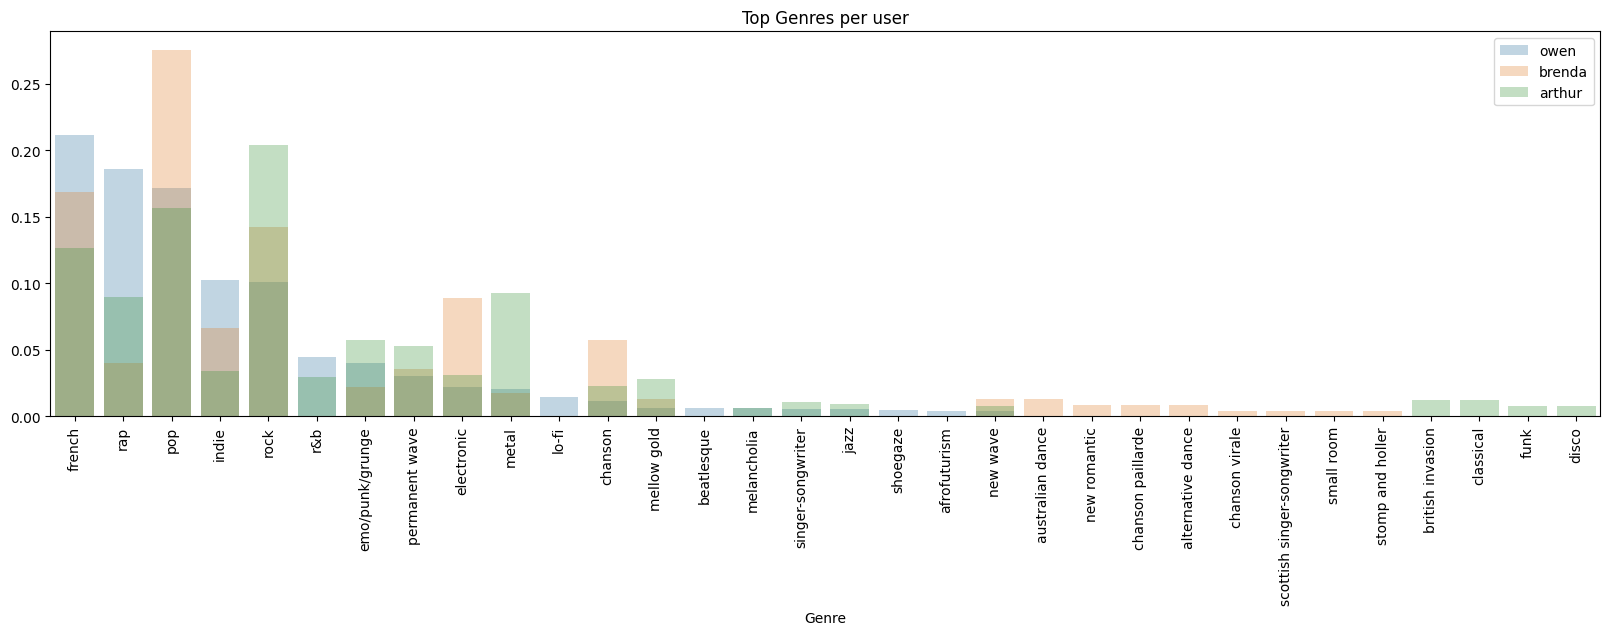

In [14]:
plt.figure(figsize=(20,5))

for i, user in enumerate(USERS):
    all_genres = pd.Series([genre for genres in USERS_DF[i]["simplified_genres"] for genre in genres])
    all_genres_count = all_genres.value_counts()[:20]
    all_genres_count /= all_genres_count.sum()
    sns.barplot(x=all_genres_count.index, y=all_genres_count.values, label=user.username, alpha=0.3)

plt.title(f"Top Genres per user")
plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.show()

In [15]:
numeric_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "loudness",
    "duration_ms",
]

<Figure size 2000x1000 with 0 Axes>

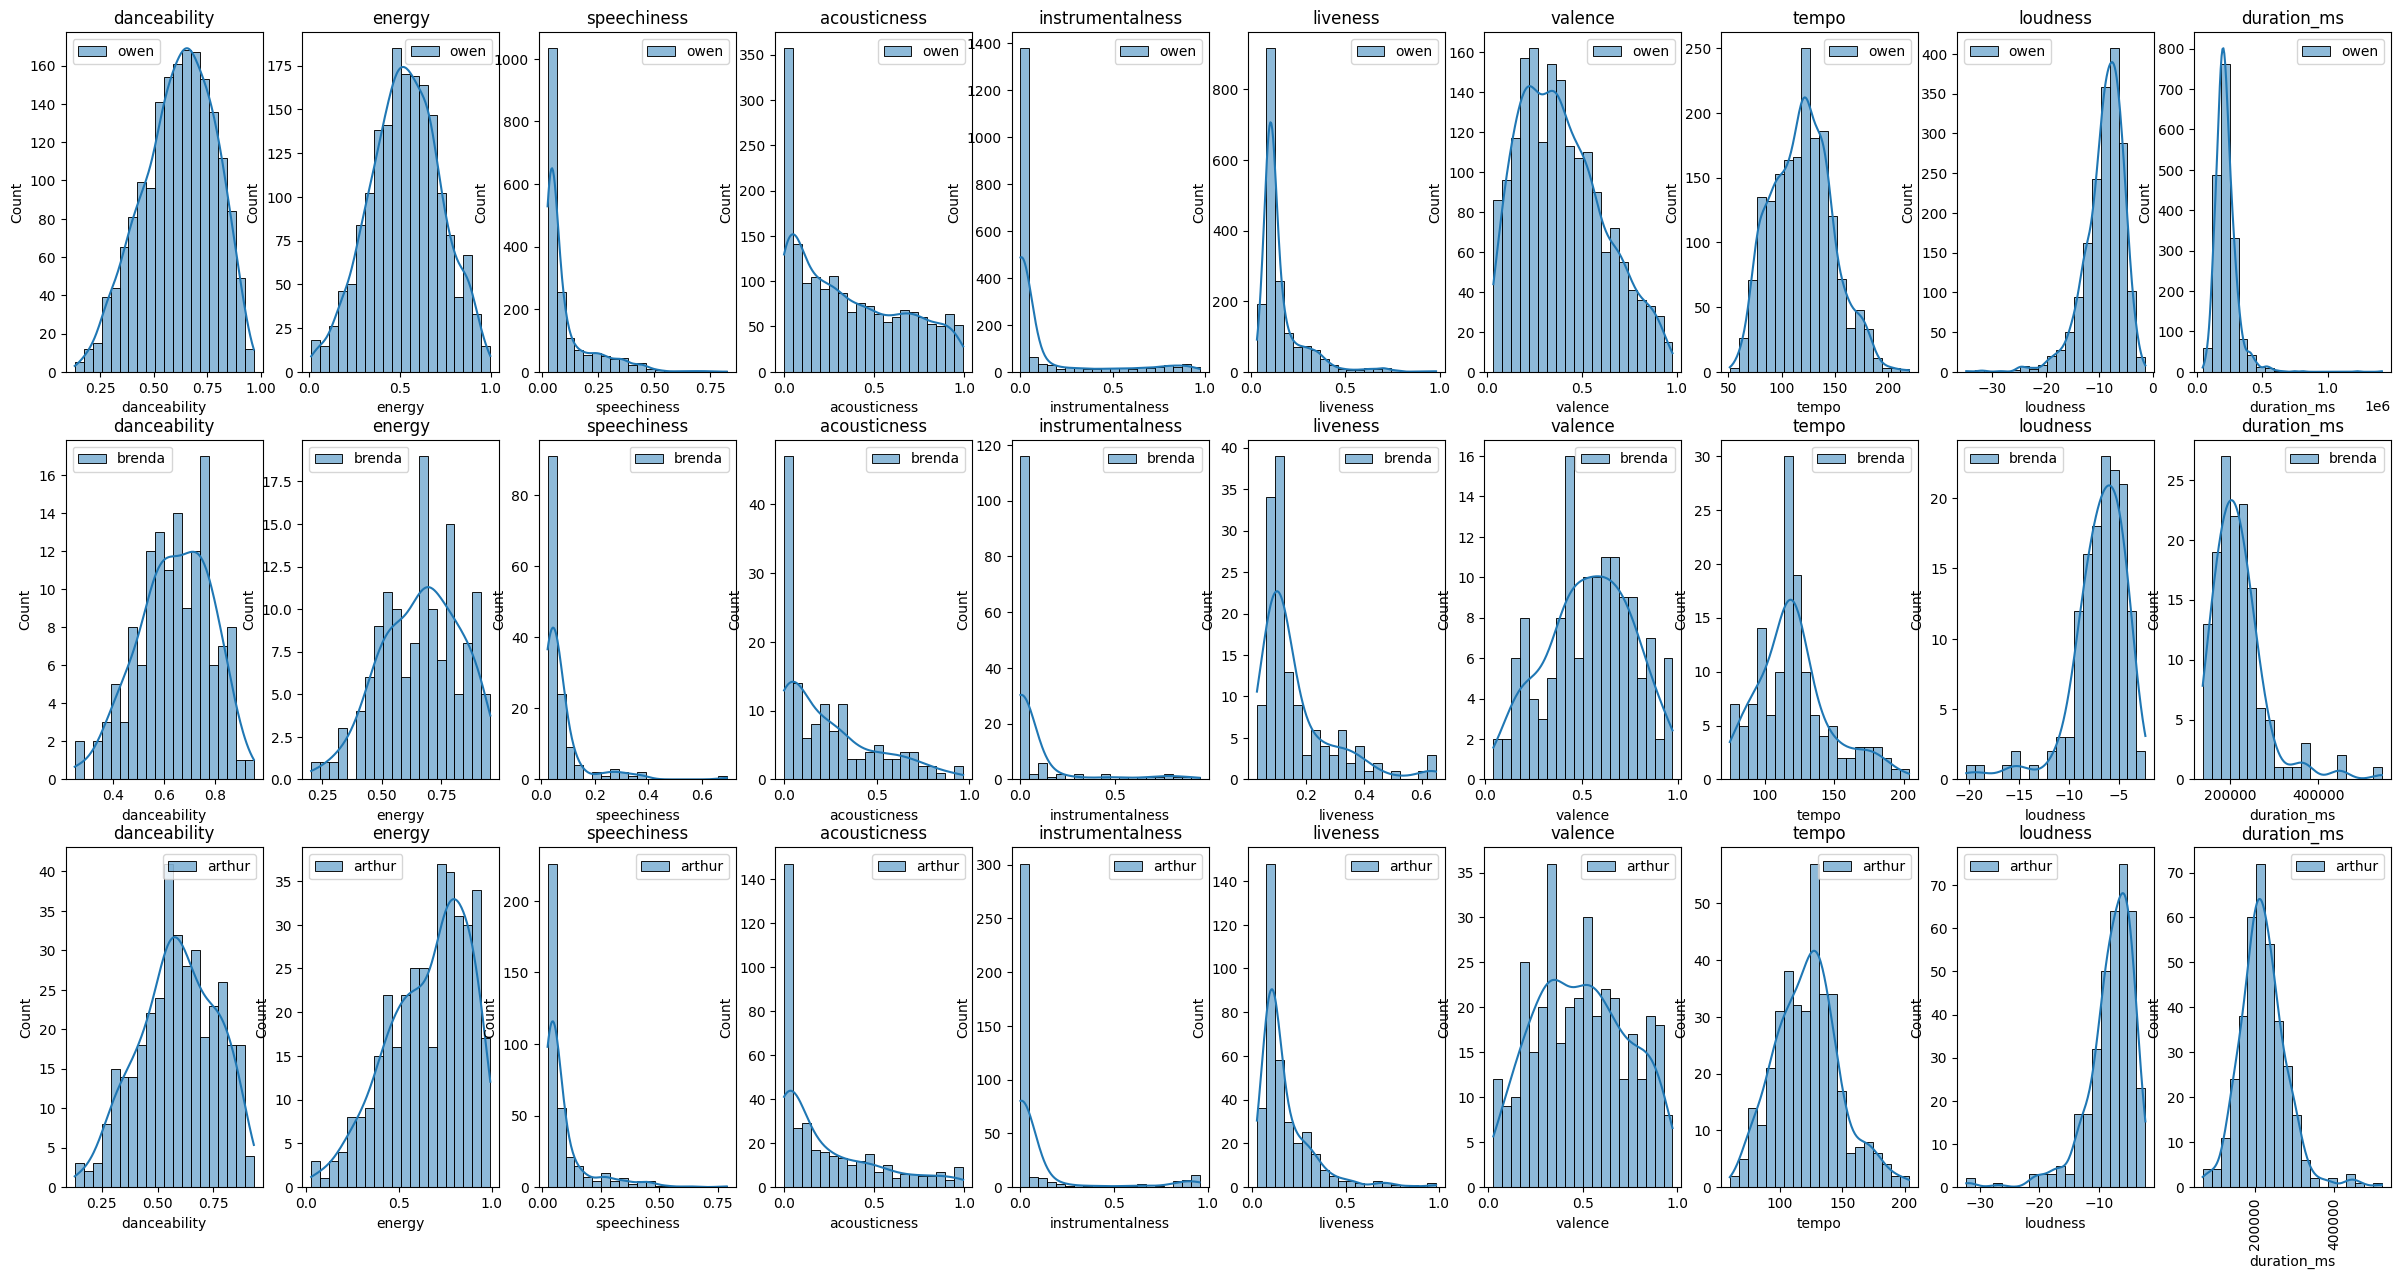

In [16]:
plt.figure(figsize=(20,10))

fig, axs = plt.subplots(len(USERS), len(numeric_features), figsize=(30, len(USERS)*5))

for i, user in enumerate(USERS):
    # Show features distribution for each user
    user_top_tracks = USERS_DF[i]
    for i, feature in enumerate(numeric_features):
        sns.histplot(x=feature, data=user_top_tracks, ax=axs[USERS.index(user), i], bins=20, kde=True, label=user.username)
        axs[USERS.index(user), i].set_title(feature)
        axs[USERS.index(user), i].legend()

plt.legend()
plt.xticks(rotation=90)
plt.show()

<Figure size 2000x1000 with 0 Axes>

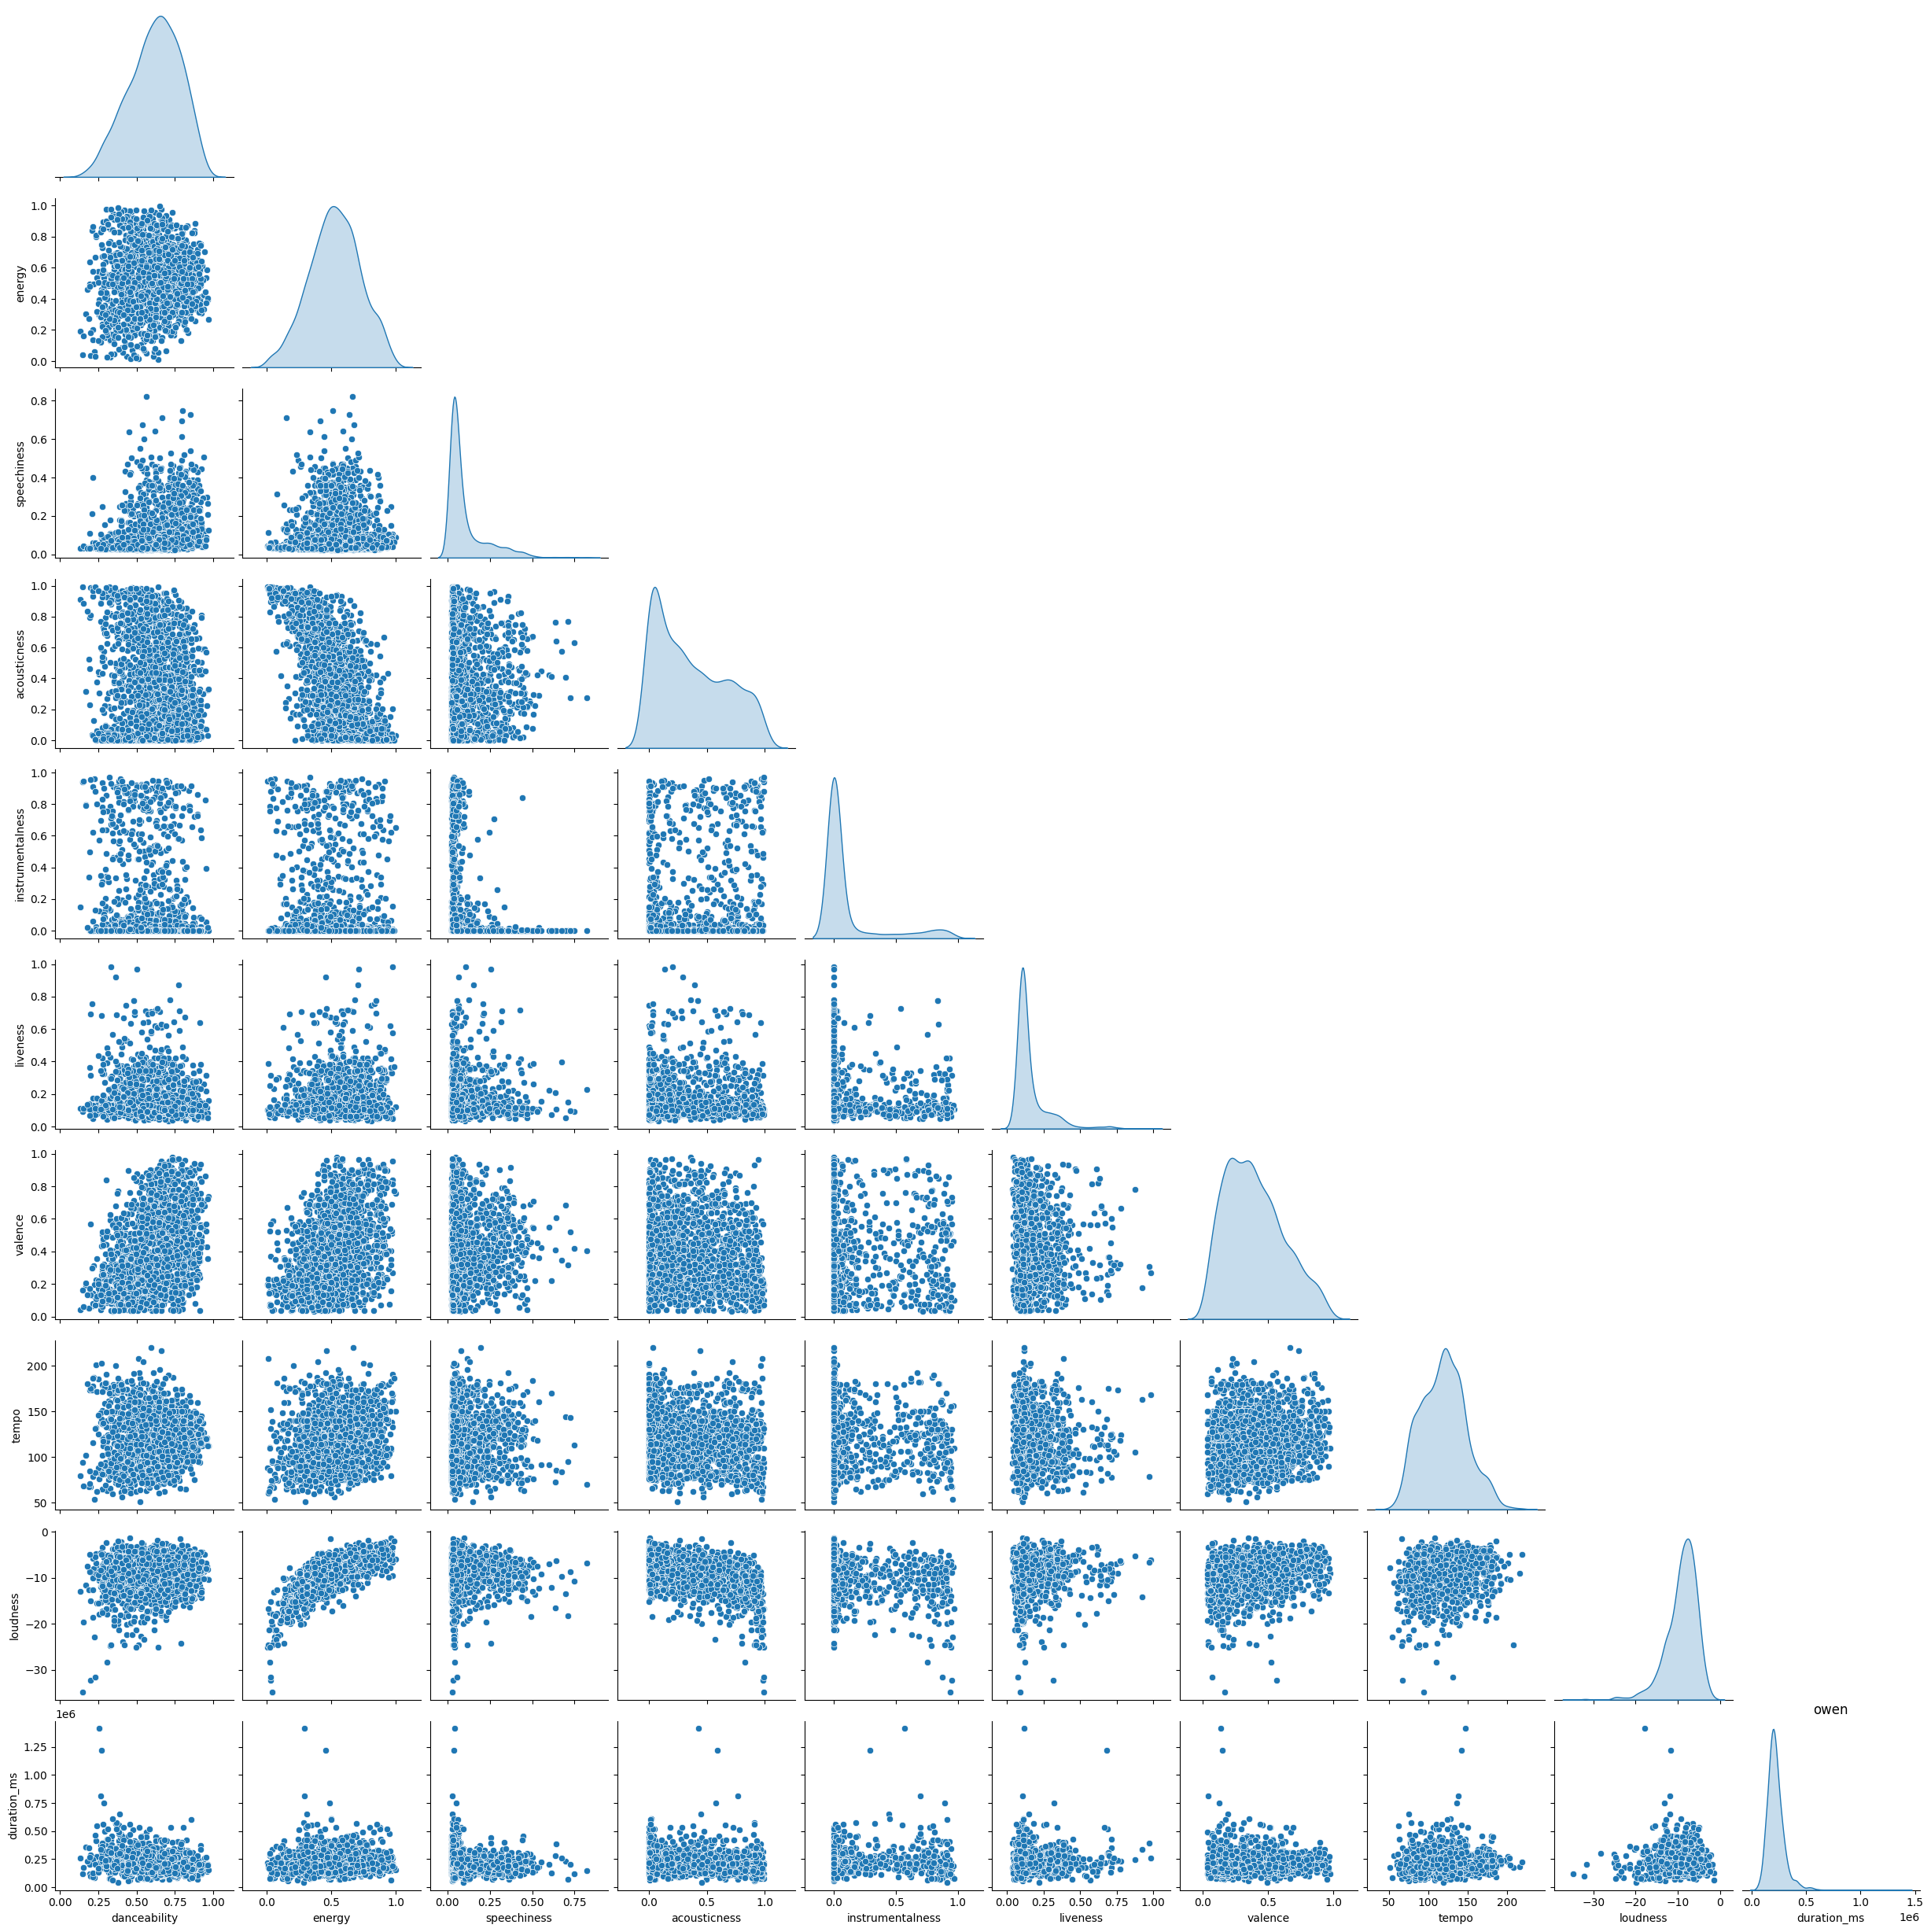

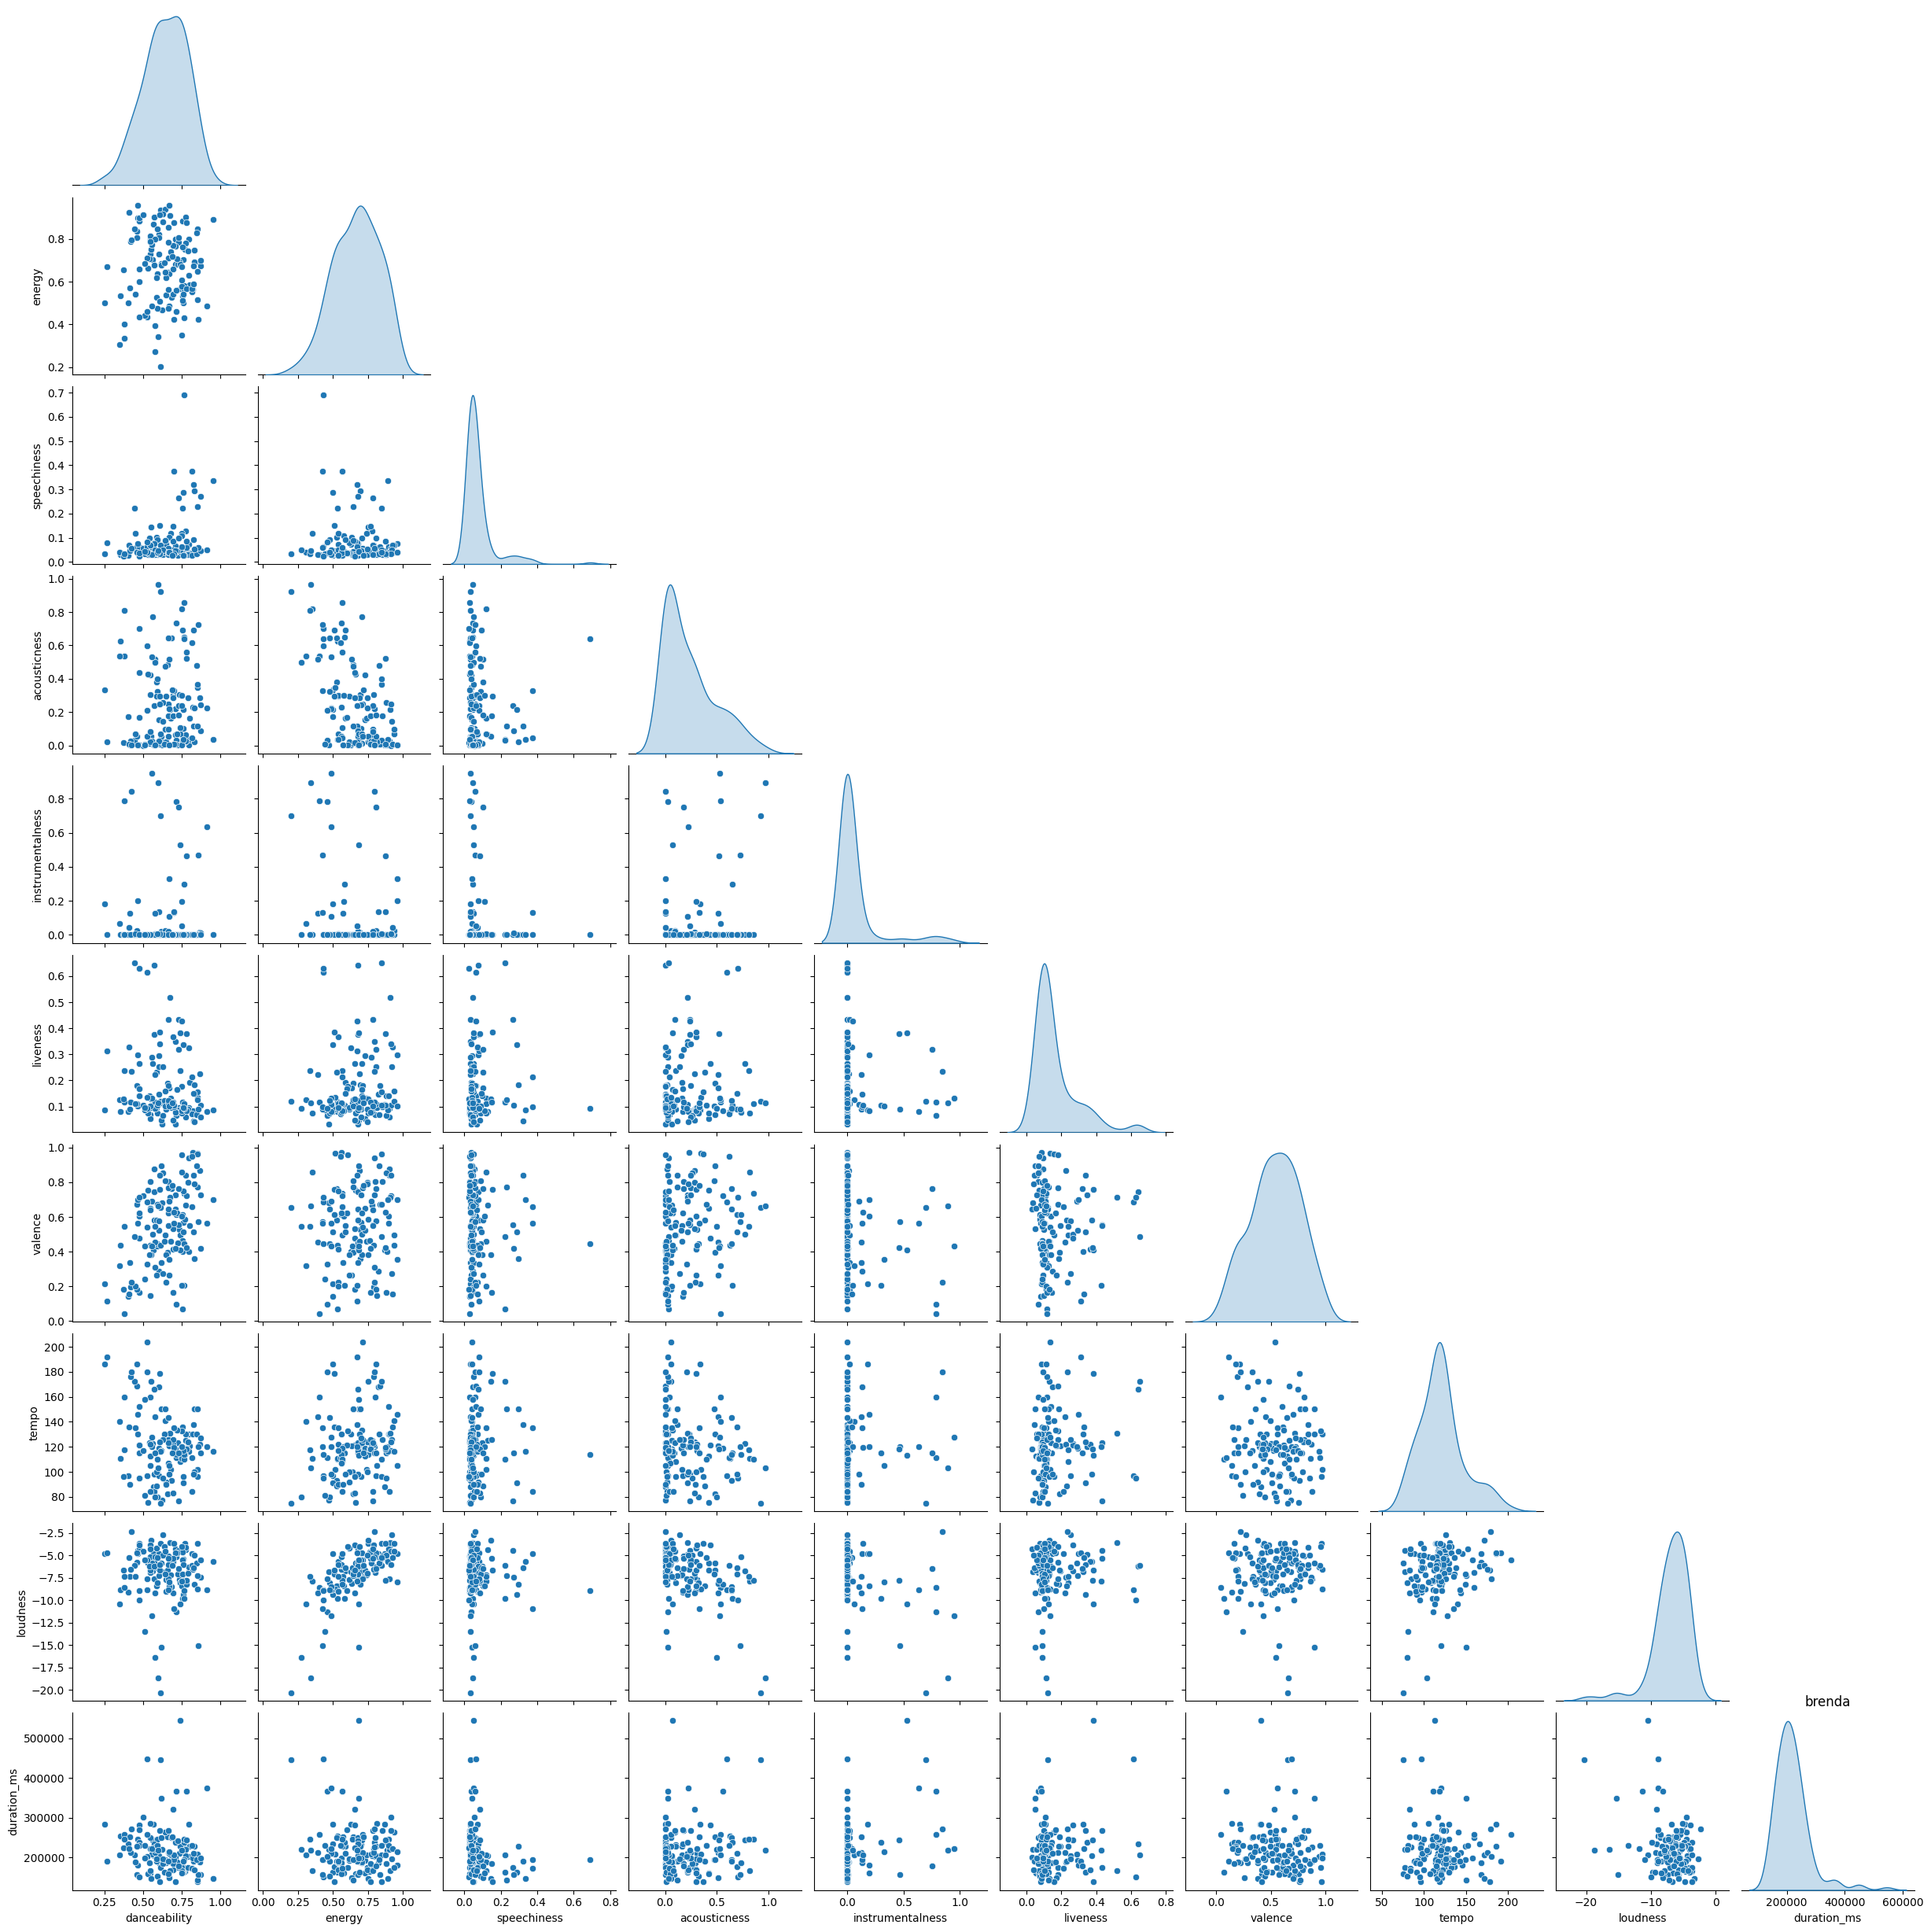

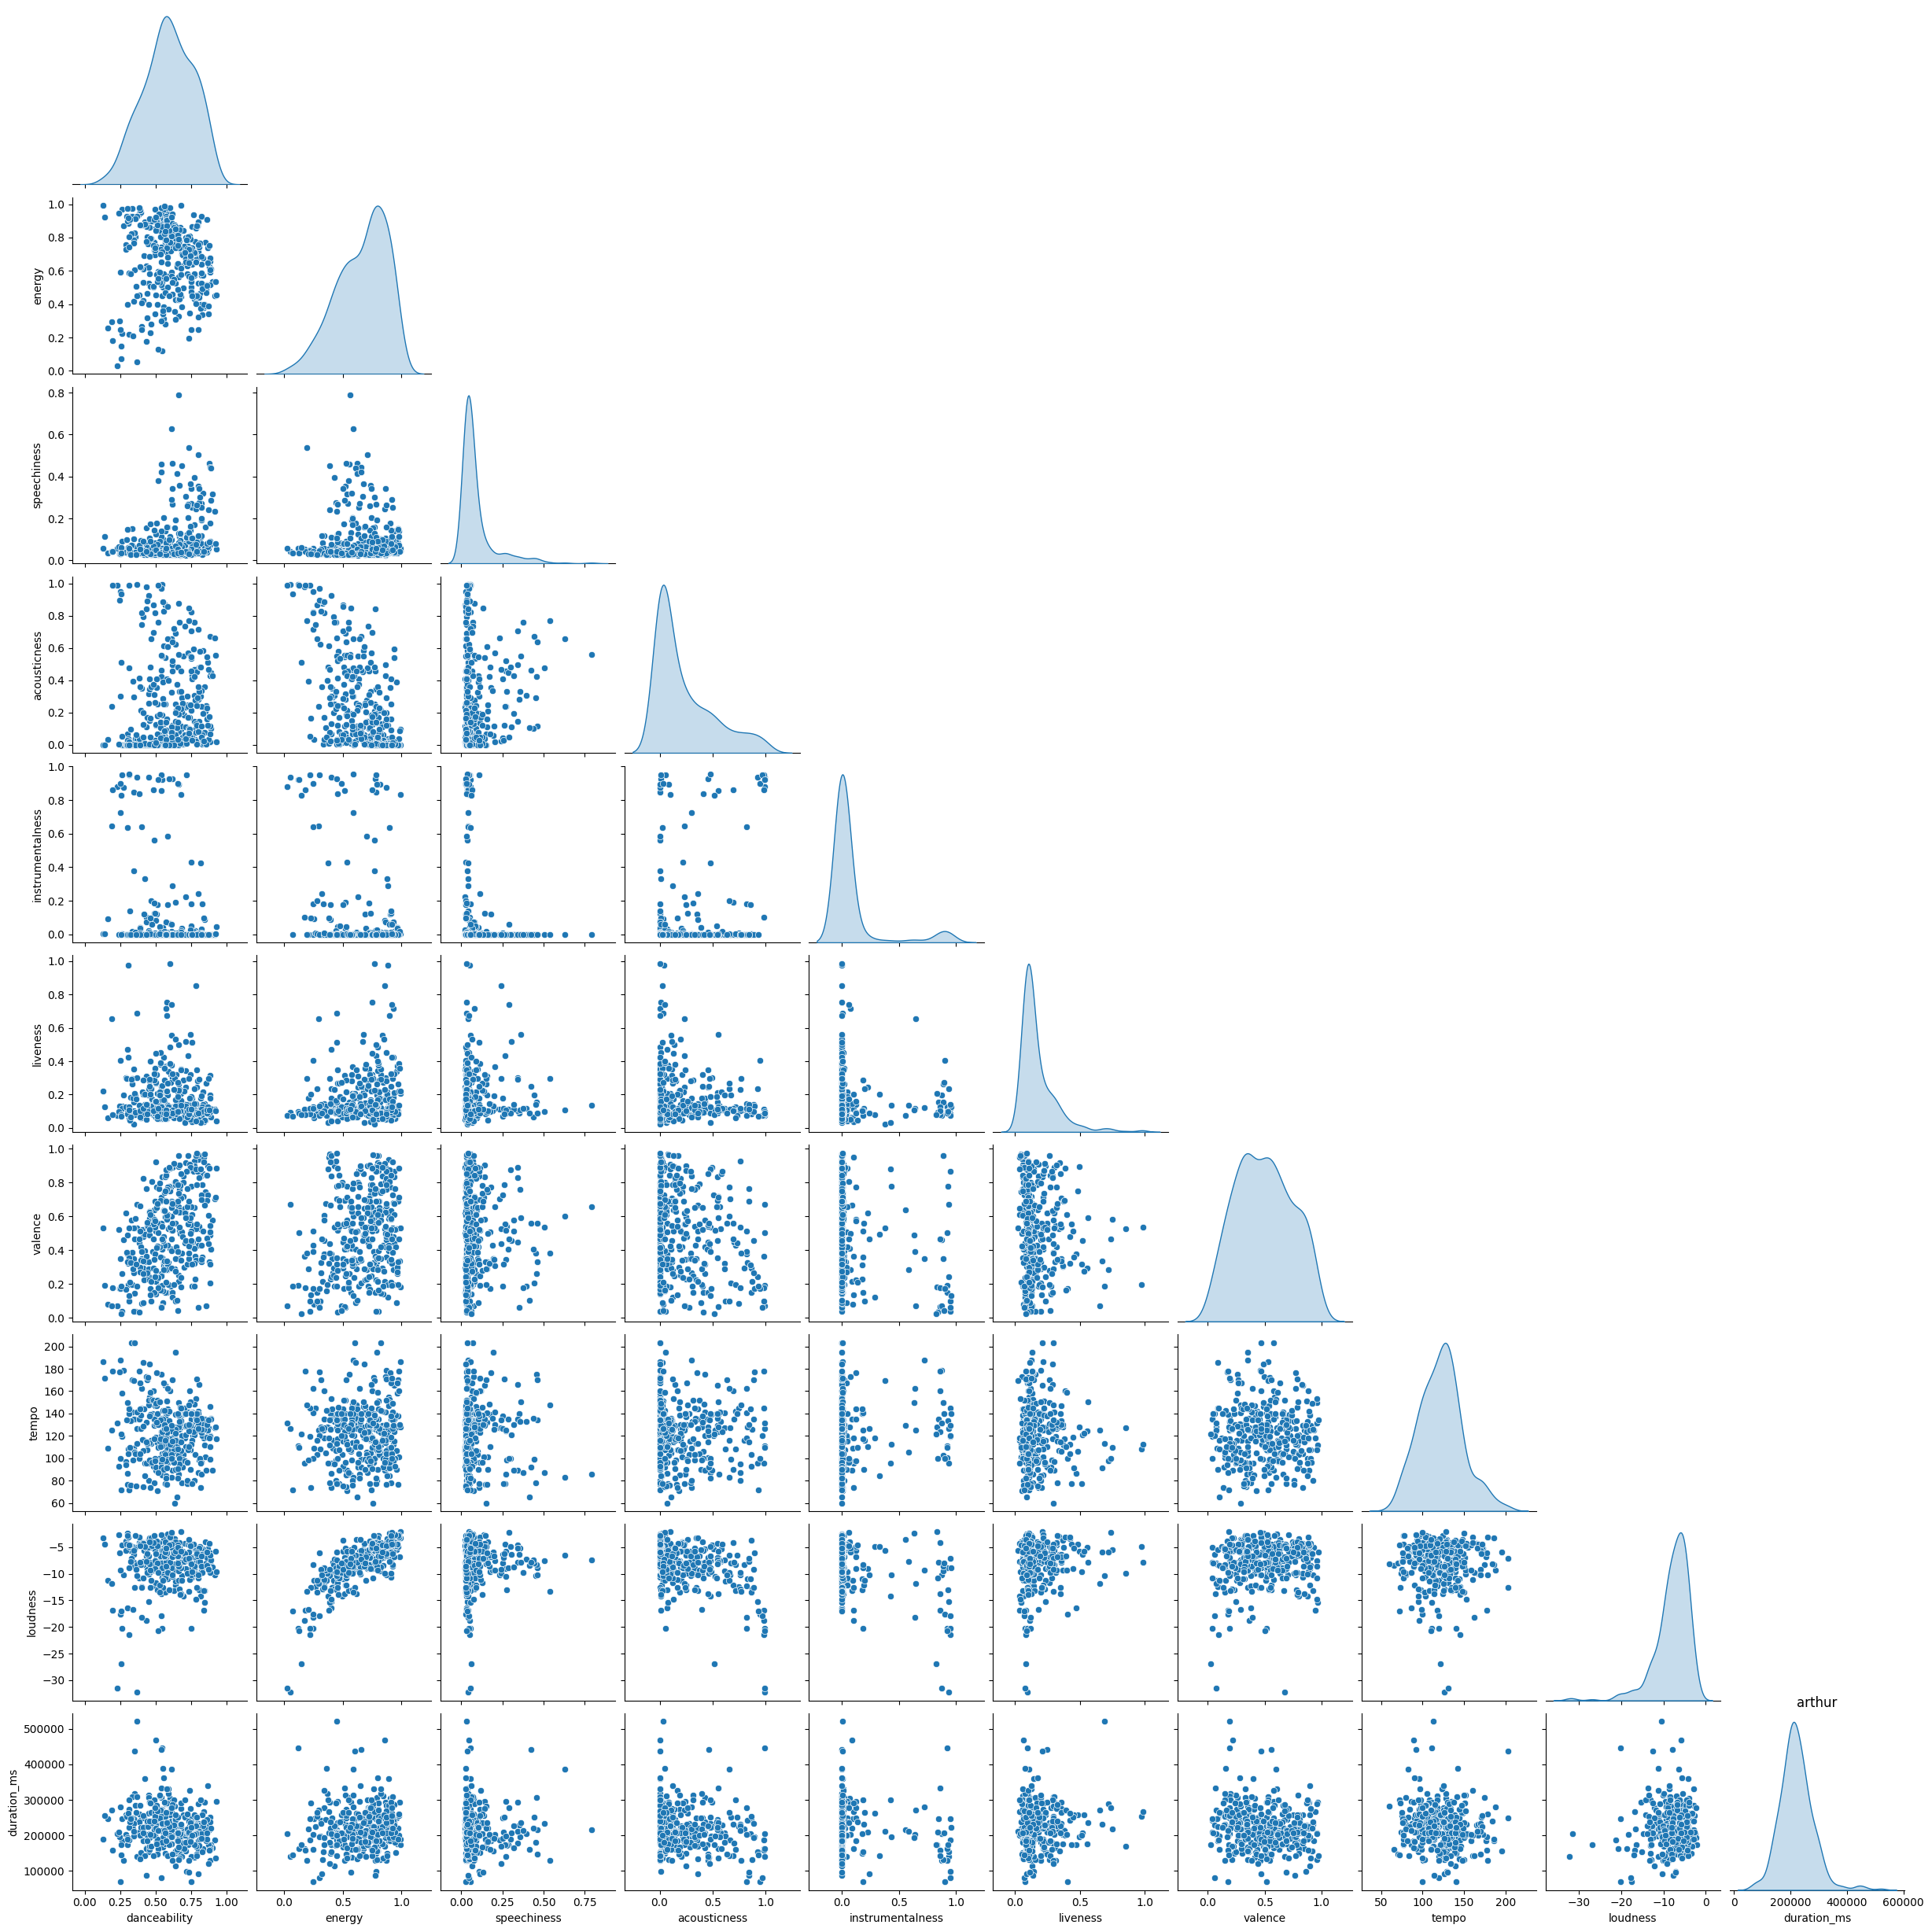

In [17]:
plt.figure(figsize=(20,10))

for i, user in enumerate(USERS):
    # Show features distribution for each user
    user_top_tracks = USERS_DF[i]
    sns.pairplot(user_top_tracks[numeric_features], diag_kind="kde", corner=True)
    plt.title(user.username)